<a href="https://colab.research.google.com/github/krish73055/Computer-network/blob/main/ML_Lab_Experiments.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Exp 1 - FIND-S Algorithm

In [ ]:
data = [
    ['Sunny', 'Warm', 'Normal', 'Strong', 'Warm', 'Same', 'Yes'],
    ['Sunny', 'Warm', 'High', 'Strong', 'Warm', 'Same', 'Yes'],
    ['Rainy', 'Cold', 'High', 'Strong', 'Warm', 'Change', 'No'],
    ['Sunny', 'Warm', 'High', 'Strong', 'Cool', 'Change', 'Yes']
]

hypothesis = ['0', '0', '0', '0', '0', '0']

for row in data:
    if row[-1] == 'Yes':
        for i in range(len(hypothesis)):
            if hypothesis[i] == '0':
                hypothesis[i] = row[i]
            elif hypothesis[i] != row[i]:
                hypothesis[i] = '?'

print("Most Specific Hypothesis:")
print(hypothesis)

Most Specific Hypothesis:
['Sunny', 'Warm', '?', 'Strong', '?', '?']


In [ ]:
#Exp 2 - Candidate-Elimination Algorithm

In [ ]:
data = [
    ['Sunny', 'Warm', 'Normal', 'Strong', 'Warm', 'Same', 'Yes'],
    ['Sunny', 'Warm', 'High', 'Strong', 'Warm', 'Same', 'Yes'],
    ['Rainy', 'Cold', 'High', 'Strong', 'Warm', 'Change', 'No'],
    ['Sunny', 'Warm', 'High', 'Strong', 'Cool', 'Change', 'Yes']
]

n = len(data[0]) - 1

S = ['0'] * n
G = [['?'] * n]

for example in data:
    x = example[:-1]
    label = example[-1]

    if label == 'Yes':
        for i in range(n):
            if S[i] == '0':
                S[i] = x[i]
            elif S[i] != x[i]:
                S[i] = '?'

        G = [g for g in G if all(
            g[i] == '?' or g[i] == S[i] for i in range(n)
        )]

    else:
        new_G = []
        for g in G:
            for i in range(n):
                if g[i] == '?':
                    if S[i] != '?':
                        new_g = g.copy()
                        new_g[i] = S[i]
                        new_G.append(new_g)
        G = new_G

print("Specific Boundary:")
print(S)

print("\nGeneral Boundary:")
for g in G:
    print(g)

Specific Boundary:
['Sunny', 'Warm', '?', 'Strong', '?', '?']

General Boundary:
['Sunny', '?', '?', '?', '?', '?']
['?', 'Warm', '?', '?', '?', '?']
['?', '?', '?', 'Strong', '?', '?']


In [ ]:
#Exp 3 - ID3 Decision Tree

Prediction: No


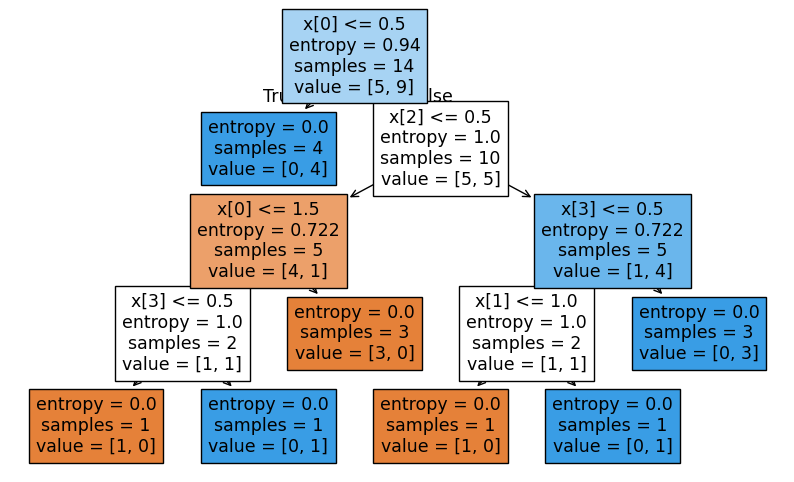

In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

data = [
    ['Sunny', 'Hot', 'High', 'Weak', 'No'],
    ['Sunny', 'Hot', 'High', 'Strong', 'No'],
    ['Overcast', 'Hot', 'High', 'Weak', 'Yes'],
    ['Rain', 'Mild', 'High', 'Weak', 'Yes'],
    ['Rain', 'Cool', 'Normal', 'Weak', 'Yes'],
    ['Rain', 'Cool', 'Normal', 'Strong', 'No'],
    ['Overcast', 'Cool', 'Normal', 'Strong', 'Yes'],
    ['Sunny', 'Mild', 'High', 'Weak', 'No'],
    ['Sunny', 'Cool', 'Normal', 'Weak', 'Yes'],
    ['Rain', 'Mild', 'Normal', 'Weak', 'Yes'],
    ['Sunny', 'Mild', 'Normal', 'Strong', 'Yes'],
    ['Overcast', 'Mild', 'High', 'Strong', 'Yes'],
    ['Overcast', 'Hot', 'Normal', 'Weak', 'Yes'],
    ['Rain', 'Mild', 'High', 'Strong', 'No']
]

X = []
y = []

for row in data:
    X.append(row[:-1])
    y.append(row[-1])

X_encoded = []

for col in range(4):
    le = LabelEncoder()
    values = [row[col] for row in X]
    X_encoded.append(le.fit_transform(values))

X_encoded = list(zip(*X_encoded))

model = DecisionTreeClassifier(criterion='entropy')
model.fit(X_encoded, y)

sample = [['Sunny', 'Cool', 'High', 'Strong']]

encoded_sample = []

for i in range(4):
    le = LabelEncoder()
    values = [row[i] for row in X]
    le.fit(values)
    encoded_sample.append(le.transform([sample[0][i]])[0])

prediction = model.predict([encoded_sample])

print("Prediction:", prediction[0])

plt.figure(figsize=(10, 6))
plot_tree(model, filled=True)
plt.show()

In [ ]:
#Exp 4 - Artificial Neural Network using Backpropagation

In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

iris = load_iris()

X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = MLPClassifier(
    hidden_layer_sizes=(10, 8),
    activation='relu',
    solver='adam',
    max_iter=1000,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Predicted Values:")
print(y_pred)

print("Actual Values:")
print(y_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Predicted Values:
[1 0 2 1 1 0 1 2 2 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]
Actual Values:
[1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]
Accuracy: 0.9666666666666667


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


In [ ]:
#Exp 5 - K-Nearest Neighbours (K-NN)

In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

iris = load_iris()

X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = KNeighborsClassifier(n_neighbors=5)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Predictions:")
print(y_pred)

print("Accuracy:", accuracy_score(y_test, y_pred))

Predictions:
[1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]
Accuracy: 1.0


In [ ]:
#Exp 6 - Naïve Bayes with Confusion Matrix and Accuracy

In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, accuracy_score

iris = load_iris()

X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = GaussianNB()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("Accuracy:")
print(accuracy_score(y_test, y_pred))

Confusion Matrix:
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
Accuracy:
1.0


In [ ]:
#Exp 7 - Logistic Regression

In [ ]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

data = load_breast_cancer()

X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = LogisticRegression(max_iter=2000)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9736842105263158


In [ ]:
#Exp 8 - Linear Regression

In [ ]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

X = np.array([[1], [2], [3], [4], [5], [6]])
y = np.array([2, 4, 6, 8, 10, 12])

model = LinearRegression()

model.fit(X, y)

y_pred = model.predict(X)

print("Coefficient:", model.coef_[0])
print("Intercept:", model.intercept_)

print("Predicted Values:")
print(y_pred)

print("Mean Squared Error:",
      mean_squared_error(y, y_pred))

print("R2 Score:",
      r2_score(y, y_pred))

print("Prediction for X = 7:",
      model.predict([[7]])[0])

Coefficient: 1.9999999999999996
Intercept: 1.7763568394002505e-15
Predicted Values:
[ 2.  4.  6.  8. 10. 12.]
Mean Squared Error: 9.532069271420559e-31
R2 Score: 1.0
Prediction for X = 7: 13.999999999999998


In [ ]:
#Exp 9 - Linear vs Polynomial Regression

Linear Regression R2: 0.8950757447385366
Polynomial Regression R2: 0.9981235406219309


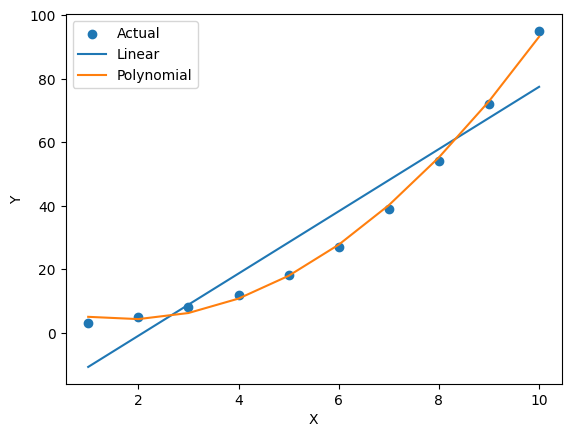

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score

X = np.arange(1, 11).reshape(-1, 1)

y = np.array([
    3, 5, 8, 12, 18,
    27, 39, 54, 72, 95
])

linear_model = LinearRegression()
linear_model.fit(X, y)

linear_pred = linear_model.predict(X)

poly = PolynomialFeatures(degree=2)

X_poly = poly.fit_transform(X)

poly_model = LinearRegression()
poly_model.fit(X_poly, y)

poly_pred = poly_model.predict(X_poly)

print("Linear Regression R2:",
      r2_score(y, linear_pred))

print("Polynomial Regression R2:",
      r2_score(y, poly_pred))

plt.scatter(X, y, label="Actual")
plt.plot(X, linear_pred, label="Linear")
plt.plot(X, poly_pred, label="Polynomial")

plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.show()

In [ ]:
#Exp 10 - Expectation & Maximization Algorithm

In [ ]:
import numpy as np
from sklearn.mixture import GaussianMixture

X = np.array([
    [1, 1],
    [1.2, 0.8],
    [0.8, 1.1],
    [5, 5],
    [5.2, 4.8],
    [4.8, 5.1],
    [9, 1],
    [9.2, 1.2],
    [8.8, 0.8]
])

model = GaussianMixture(
    n_components=3,
    random_state=42
)

model.fit(X)

labels = model.predict(X)

print("Cluster Labels:")
print(labels)

print("\nCluster Means:")
print(model.means_)

Cluster Labels:
[2 2 2 0 0 0 1 1 1]

Cluster Means:
[[5.         4.96666667]
 [9.         1.        ]
 [1.         0.96666667]]


In [ ]:
#Exp 11 - Credit Score Classification

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

np.random.seed(42)

n = 300

income = np.random.randint(20000, 120000, n)
age = np.random.randint(21, 65, n)
debt = np.random.randint(1000, 60000, n)
credit_history = np.random.randint(1, 20, n)

score = (
    0.00004 * income
    + 0.04 * age
    - 0.00003 * debt
    + 0.25 * credit_history
)

y = (score > np.median(score)).astype(int)

X = np.column_stack([
    income,
    age,
    debt,
    credit_history
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:",
      accuracy_score(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.95
Confusion Matrix:
[[27  1]
 [ 2 30]]


In [ ]:
#Exp 12 - Iris Flower Classification using KNN

In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

iris = load_iris()

X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42
)

model = KNeighborsClassifier(n_neighbors=3)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

sample = [[5.1, 3.5, 1.4, 0.2]]

prediction = model.predict(sample)

print("Predicted Flower:",
      iris.target_names[prediction[0]])

Accuracy: 1.0
Predicted Flower: setosa


In [ ]:
#Exp 13 - Car Price Prediction

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

data = pd.DataFrame({
    'Age': [1, 2, 3, 4, 5, 1, 2, 3, 4, 5],
    'Kilometers': [
        10000, 20000, 30000, 40000, 50000,
        12000, 22000, 32000, 42000, 52000
    ],
    'Engine': [
        1500, 1500, 1200, 1200, 1000,
        1600, 1600, 1300, 1300, 1100
    ],
    'Price': [
        900000, 820000, 700000, 600000, 500000,
        950000, 850000, 730000, 620000, 510000
    ]
})

X = data[['Age', 'Kilometers', 'Engine']]
y = data['Price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Predicted Prices:")
print(y_pred)

print("MAE:",
      mean_absolute_error(y_test, y_pred))

print("R2 Score:",
      r2_score(y_test, y_pred))

new_car = [[2, 18000, 1500]]

print("Predicted Price:",
      model.predict(new_car)[0])

Predicted Prices:
[632815.67489115 815849.05660377]
MAE: 8483.309143686492
R2 Score: 0.9909264073002879
Predicted Price: 792264.1509433963


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [ ]:
#Exp 14 - House Price Prediction

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

data = pd.DataFrame({
    'Area': [800, 1000, 1200, 1500, 1800,
             2000, 2200, 2500, 2800, 3000],

    'Bedrooms': [2, 2, 3, 3, 3,
                 4, 4, 4, 5, 5],

    'Age': [20, 15, 10, 8, 7,
            5, 4, 3, 2, 1],

    'Price': [
        2500000, 3000000, 3600000, 4500000,
        5200000, 6000000, 6500000, 7500000,
        8500000, 9500000
    ]
})

X = data[['Area', 'Bedrooms', 'Age']]
y = data['Price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("MAE:",
      mean_absolute_error(y_test, y_pred))

print("R2 Score:",
      r2_score(y_test, y_pred))

new_house = [[1800, 3, 5]]

print("Predicted House Price:",
      model.predict(new_house)[0])

MAE: 162500.0
R2 Score: 0.9957140495867769
Predicted House Price: 5467000.0


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [ ]:
#Exp 15 - Iris Flower Classification using Naïve Bayes

In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix

iris = load_iris()

X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42
)

model = GaussianNB()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:",
      accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

sample = [[5.1, 3.5, 1.4, 0.2]]

prediction = model.predict(sample)

print("\nPredicted Flower:",
      iris.target_names[prediction[0]])

Accuracy: 1.0

Confusion Matrix:
[[15  0  0]
 [ 0 11  0]
 [ 0  0 12]]

Predicted Flower: setosa


In [ ]:
#Exp 16 - Comparison of Classification Algorithms

In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score

iris = load_iris()

X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

models = {
    "KNN": make_pipeline(
        StandardScaler(),
        KNeighborsClassifier(n_neighbors=5)
    ),

    "Decision Tree":
        DecisionTreeClassifier(random_state=42),

    "Naive Bayes":
        GaussianNB(),

    "Logistic Regression": make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=1000)
    ),

    "SVM": make_pipeline(
        StandardScaler(),
        SVC()
    )
}

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    print(name, "Accuracy:", accuracy)

KNN Accuracy: 1.0
Decision Tree Accuracy: 1.0
Naive Bayes Accuracy: 1.0
Logistic Regression Accuracy: 1.0
SVM Accuracy: 1.0


In [ ]:
#Exp 17 - Mobile Price Prediction

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

data = pd.DataFrame({
    'RAM': [2, 3, 4, 4, 6, 8, 8, 12, 12, 16],

    'Storage': [
        32, 64, 64, 128, 128,
        128, 256, 256, 512, 512
    ],

    'Battery': [
        3000, 3500, 4000, 4500, 4500,
        5000, 5000, 5500, 5500, 6000
    ],

    'Camera': [
        8, 12, 16, 24, 32,
        48, 50, 64, 108, 200
    ],

    'Price_Class': [
        0, 0, 0, 1, 1,
        1, 2, 2, 3, 3
    ]
})

X = data.drop('Price_Class', axis=1)
y = data['Price_Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:",
      accuracy_score(y_test, y_pred))

mobile = [[8, 256, 5000, 64]]

print("Predicted Price Class:",
      model.predict(mobile)[0])

Accuracy: 0.5
Predicted Price Class: 2


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [ ]:
#Exp 18 - Perceptron Based IRIS Classification

In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score

iris = load_iris()

X = iris.data

# Binary classification:
# Setosa = 1, Other classes = 0
y = (iris.target == 0).astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

model = Perceptron(
    max_iter=1000,
    eta0=0.1,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:",
      accuracy_score(y_test, y_pred))

sample = [[5.1, 3.5, 1.4, 0.2]]

print("Prediction:",
      model.predict(sample)[0])

Accuracy: 1.0
Prediction: 1


In [ ]:
#Exp 19 - Naïve Bayes Classification for Bank Loan Prediction

In [ ]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix

data = pd.DataFrame({
    'Age': [
        25, 35, 45, 23, 52, 40,
        29, 60, 33, 48, 27, 55
    ],

    'Income': [
        30000, 60000, 90000, 25000,
        100000, 75000, 45000, 120000,
        55000, 85000, 35000, 110000
    ],

    'LoanAmount': [
        5000, 15000, 30000, 4000,
        25000, 20000, 10000, 35000,
        12000, 28000, 7000, 30000
    ],

    'CreditScore': [
        650, 720, 780, 620,
        800, 750, 680, 820,
        710, 770, 640, 810
    ],

    'LoanApproved': [
        'No', 'Yes', 'Yes', 'No',
        'Yes', 'Yes', 'No', 'Yes',
        'Yes', 'Yes', 'No', 'Yes'
    ]
})

X = data[
    ['Age', 'Income', 'LoanAmount', 'CreditScore']
]

encoder = LabelEncoder()

y = encoder.fit_transform(
    data['LoanApproved']
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42
)

model = GaussianNB()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:",
      accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

new_customer = [[35, 70000, 15000, 740]]

prediction = model.predict(new_customer)

print("\nLoan Prediction:",
      encoder.inverse_transform(prediction)[0])

Accuracy: 1.0

Confusion Matrix:
[[2 0]
 [0 1]]

Loan Prediction: Yes


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(


In [ ]:
#Exp 20 - Future Sales Prediction

Future Sales Prediction:
Month 13 = 297.95
Month 14 = 313.02
Month 15 = 328.09
Month 16 = 343.16
Month 17 = 358.23
Month 18 = 373.3

Mean Absolute Error: 2.9574592074591983


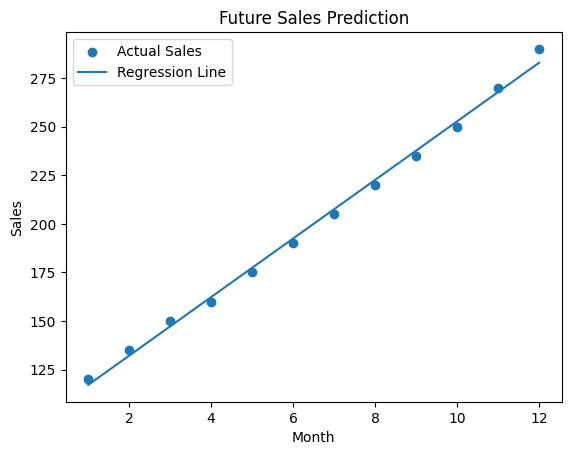

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

months = np.arange(1, 13).reshape(-1, 1)

sales = np.array([
    120, 135, 150, 160,
    175, 190, 205, 220,
    235, 250, 270, 290
])

model = LinearRegression()

model.fit(months, sales)

predicted_sales = model.predict(months)

future_months = np.array([
    [13], [14], [15],
    [16], [17], [18]
])

future_sales = model.predict(future_months)

print("Future Sales Prediction:")

for month, sale in zip(
    future_months.flatten(),
    future_sales
):
    print(
        "Month", month,
        "=", round(sale, 2)
    )

print("\nMean Absolute Error:",
      mean_absolute_error(
          sales,
          predicted_sales
      ))

plt.scatter(months, sales, label="Actual Sales")
plt.plot(
    months,
    predicted_sales,
    label="Regression Line"
)

plt.xlabel("Month")
plt.ylabel("Sales")
plt.title("Future Sales Prediction")
plt.legend()
plt.show()